In [1]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np

import json

In [9]:
#file_path = "2025-06-22_alle_Modelle_Datenextraktion_gemma3.json"
#file_path = "2025-07-26_alle_Modelle_Datenextraktion_gemma3.json"

def get_results_body(file_path):
    # Datei öffnen und laden
    with open(file_path, 'r') as f:
        r = json.load(f)
    # Alles außer body entfernen
    r = r['body']
    return r


file_path_1 = "2025-07-27_gemma_phi_qwen.json"
file_path_2 = "2025-07-27_mistralsmall3-1_llama_mixtral-api.json"
file_path_3 = "2025-07-27_mixtral8x7b_granite3mob_mistral7b.json"

results_1 = get_results_body(file_path_1)
results_2 = get_results_body(file_path_2)
results_3 = get_results_body(file_path_3)

results = []

for n in results_1:
    results.append(n)

for n in results_2:
    results.append(n)

for n in results_3:
    results.append(n)

# Leere Listen anlegen
provider = []
scores = []

# Dateiinhalt durchiterieren
for i in range(0,len(results)):
    for l in range(0,len(results[i]['outputs'])):
        provider.append(results[i]['outputs'][l]['provider']) # Schreibe jeden Provider in eine Liste
        scores.append(results[i]['outputs'][l]['score']) # Schreibe jeden Score in eine Liste

provider_scores_df = pd.DataFrame(data={"Provider": provider, "scores": scores})

provider_set = set(provider) # Set mit allen Providern
provider_list = list(provider_set)

result_df = pd.DataFrame(columns=['Provider', 'Result'])

for provider in range(0, len(provider_list)):
    mean = np.mean(provider_scores_df[provider_scores_df["Provider"]==provider_list[provider]]["scores"])
    #print(f'{provider_list[provider]}: {mean}')
    result_df.loc[provider] = [provider_list[provider], mean]

print(result_df.sort_values(by="Result", ascending=False))

                                             Provider    Result
2                file://retrieve1_qwen3_4b_prompt2.py  0.878125
16  file://retrieve1_mistral-small_3-1_24b_4b_prom...  0.876303
1              file://retrieve1_mistral-7b_prompt2.py  0.870824
5               file://retrieve1_gemma3_4b_prompt2.py  0.855558
9            file://retrieve1_mixtral_8x7b_prompt2.py  0.763846
14              file://retrieve1_phi_4_api_prompt2.py  0.693318
10  file://retrieve1_mistral-small_3-1_24b_4b_prom...  0.692942
7              file://retrieve1_mistral-7b_prompt1.py  0.666479
8               file://retrieve1_gemma3_4b_prompt1.py  0.637352
3                file://retrieve1_qwen3_4b_prompt1.py  0.633352
0             file://retrieve1_mixtral_api_prompt1.py  0.632569
17              file://retrieve1_phi_4_api_prompt1.py  0.630305
11         file://retrieve1_granite3mob_3b_prompt2.py  0.628782
4          file://retrieve1_granite3mob_3b_prompt1.py  0.617636
6            file://retrieve1_llama3_3_a

In [16]:
def createBoxplot(daten_boxplot, labels, titles, ueberschrift):
    # Grundlegenden Aufbau definieren und zwei Variablen zuweisen
    figure, ax = plt.subplots(nrows=1, ncols=len(daten_boxplot), figsize=(34, 15))
    for i, (daten, label, title) in enumerate(zip(daten_boxplot, labels, titles)):
        # Titel setzen
        ax[i].set_title(title)
        # Skalierung fixieren
        ax[i].set_ylim(0, 1.00)
        # Linien im Hintergrund in hellgrau setzen
        ax[i].yaxis.grid(True, linestyle="-", color="lightgrey")
        # Horizontale, hellere Linien im Abstand von 0,05 ergänzen
        ax[i].set_yticks(np.arange(0, 1.00, 0.05), minor=True)
        ax[i].grid(which='minor', alpha=0.2)
        # Boxplot die Daten und Labels zuweisen
        ax[i].boxplot(daten,
                      tick_labels=label,
                      showmeans=True,
                      meanline=True,
                      meanprops=dict(color='lightseagreen'),
                      medianprops=dict(color='lightseagreen'),
                      notch=False)
    # Schriftart auf "normal" sowie die Schriftgröße auf 14 setzen
    font = {'weight': 'normal',
            'size': 18}
    plt.rc('font', **font)
    # Boxplot ausgeben
    plt.show()
    # Diagramm für als SVG-Datei unter Analysis abspeichern
    figure.savefig(f'boxplot_{ueberschrift}.svg', format="svg")

provider_list.sort()

score_list =[provider_scores_df[provider_scores_df["Provider"]==provider_list[0]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[1]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[2]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[3]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[4]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[5]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[6]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[7]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[8]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[9]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[10]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[11]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[12]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[13]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[14]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[15]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[16]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[17]]["scores"]
]

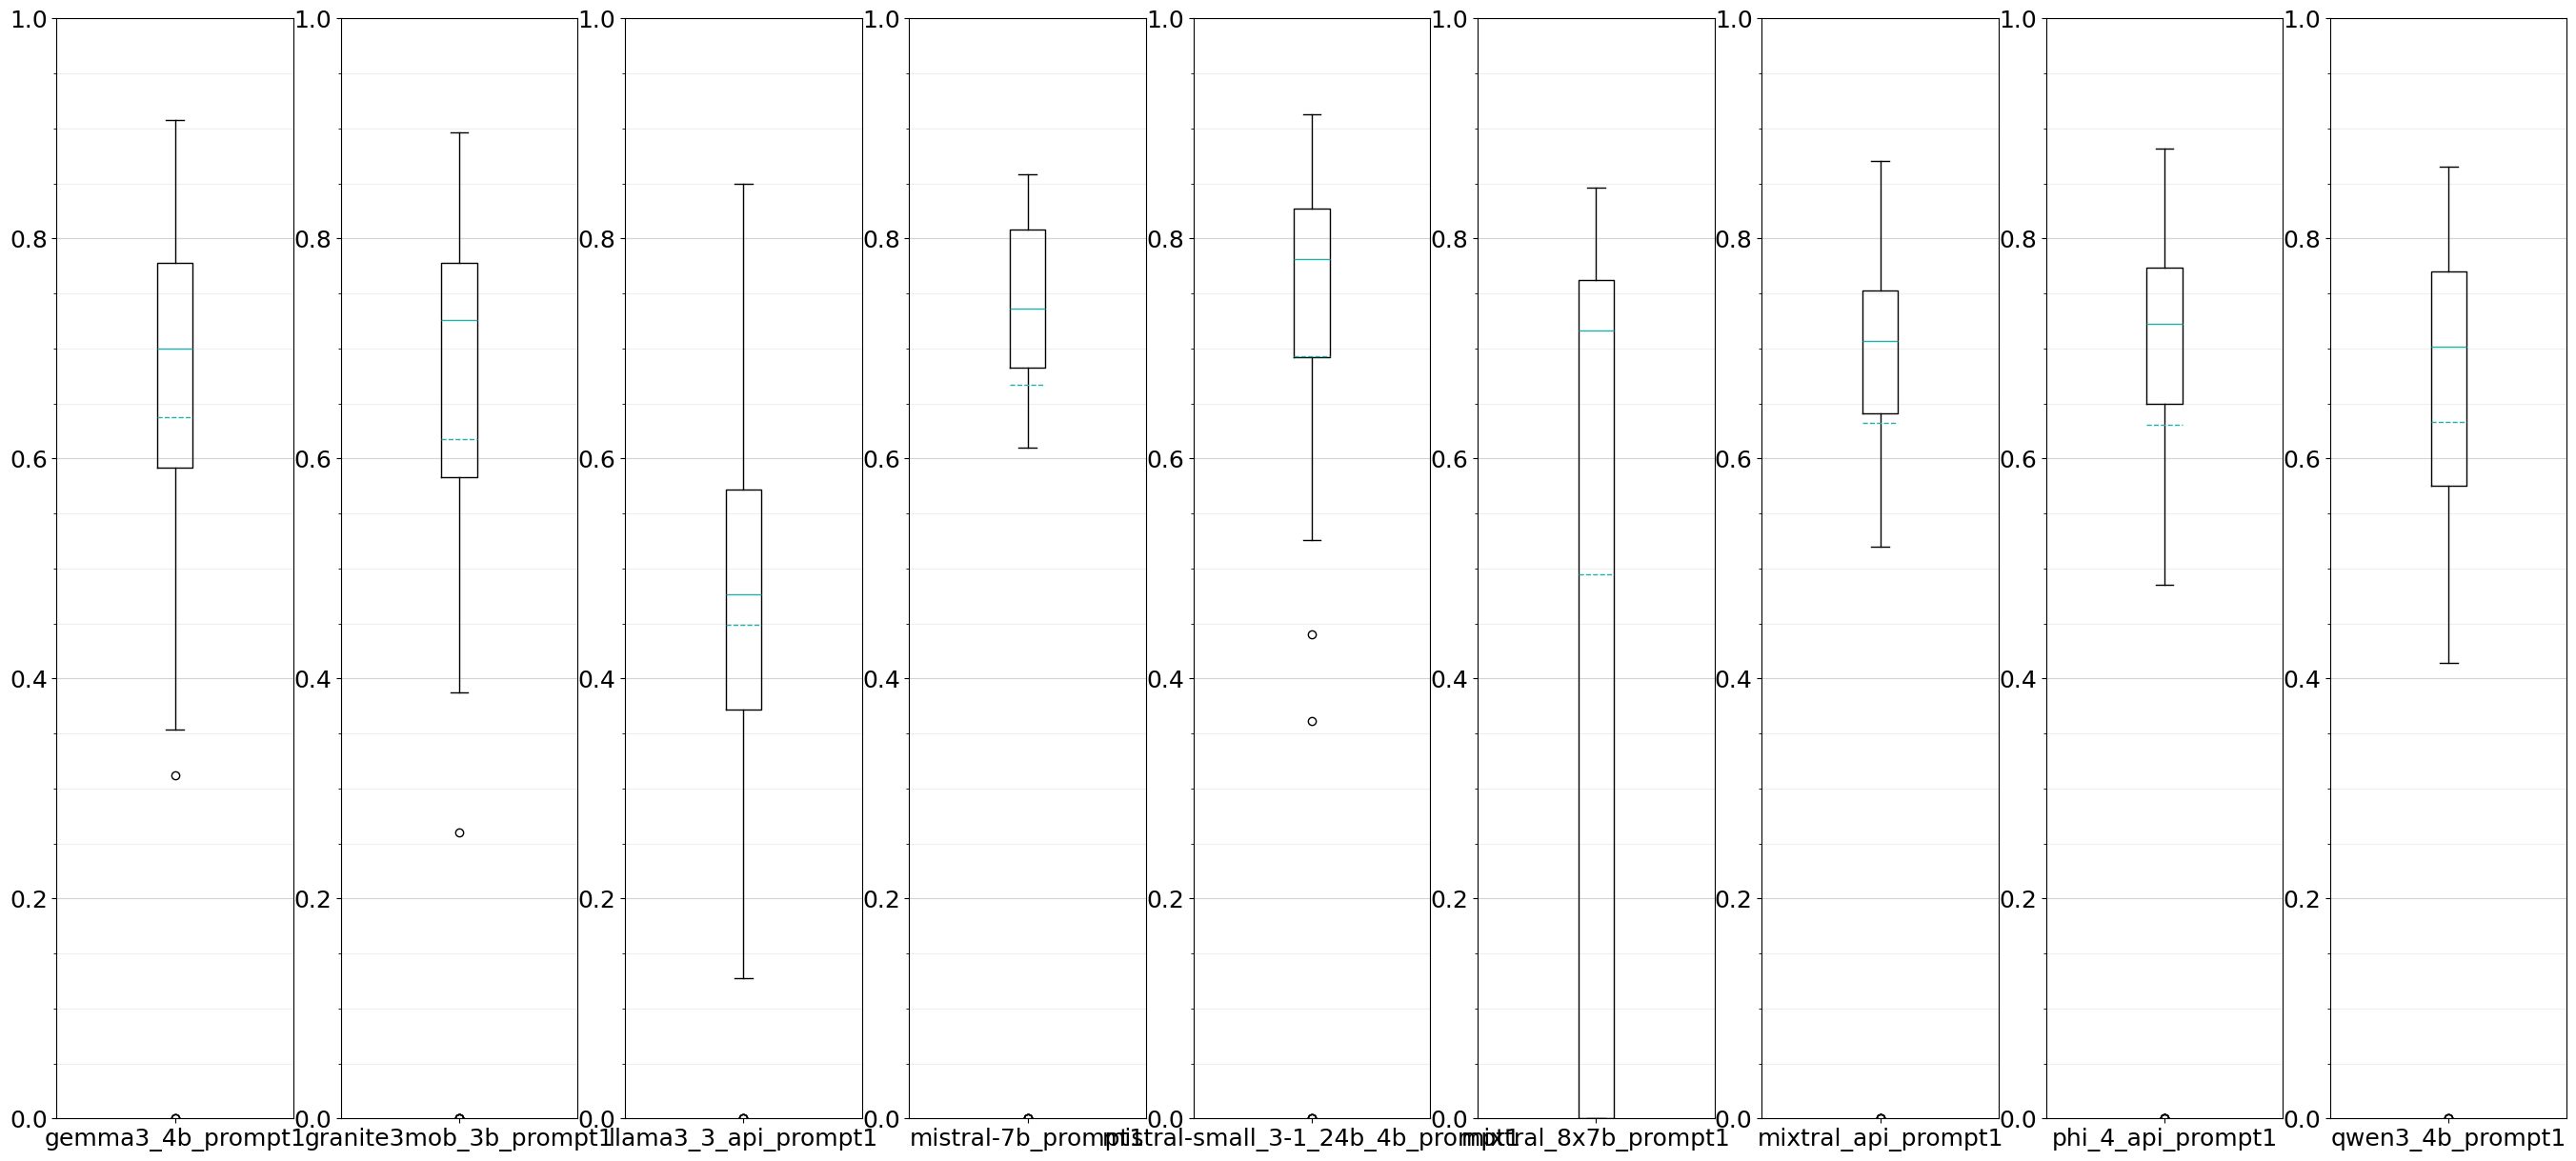

In [17]:
createBoxplot([[score_list[0]], 
               [score_list[2]],
               [score_list[4]],
               [score_list[6]],
               [score_list[8]],
               [score_list[10]],
               [score_list[12]],
               [score_list[14]],
               [score_list[16]]],
               [[provider_list[0][17:-3]],
               [provider_list[2][17:-3]],
               [provider_list[4][17:-3]],
               [provider_list[6][17:-3]],
               [provider_list[8][17:-3]],
               [provider_list[10][17:-3]],
               [provider_list[12][17:-3]],
               [provider_list[14][17:-3]],
               [provider_list[16][17:-3]]],               
               ["", "", "", "", "", "", "", "", ""],
               "Ergebnis des Prompt 1 mit Gemma3 4B zur Extrahierung der Inhalte")

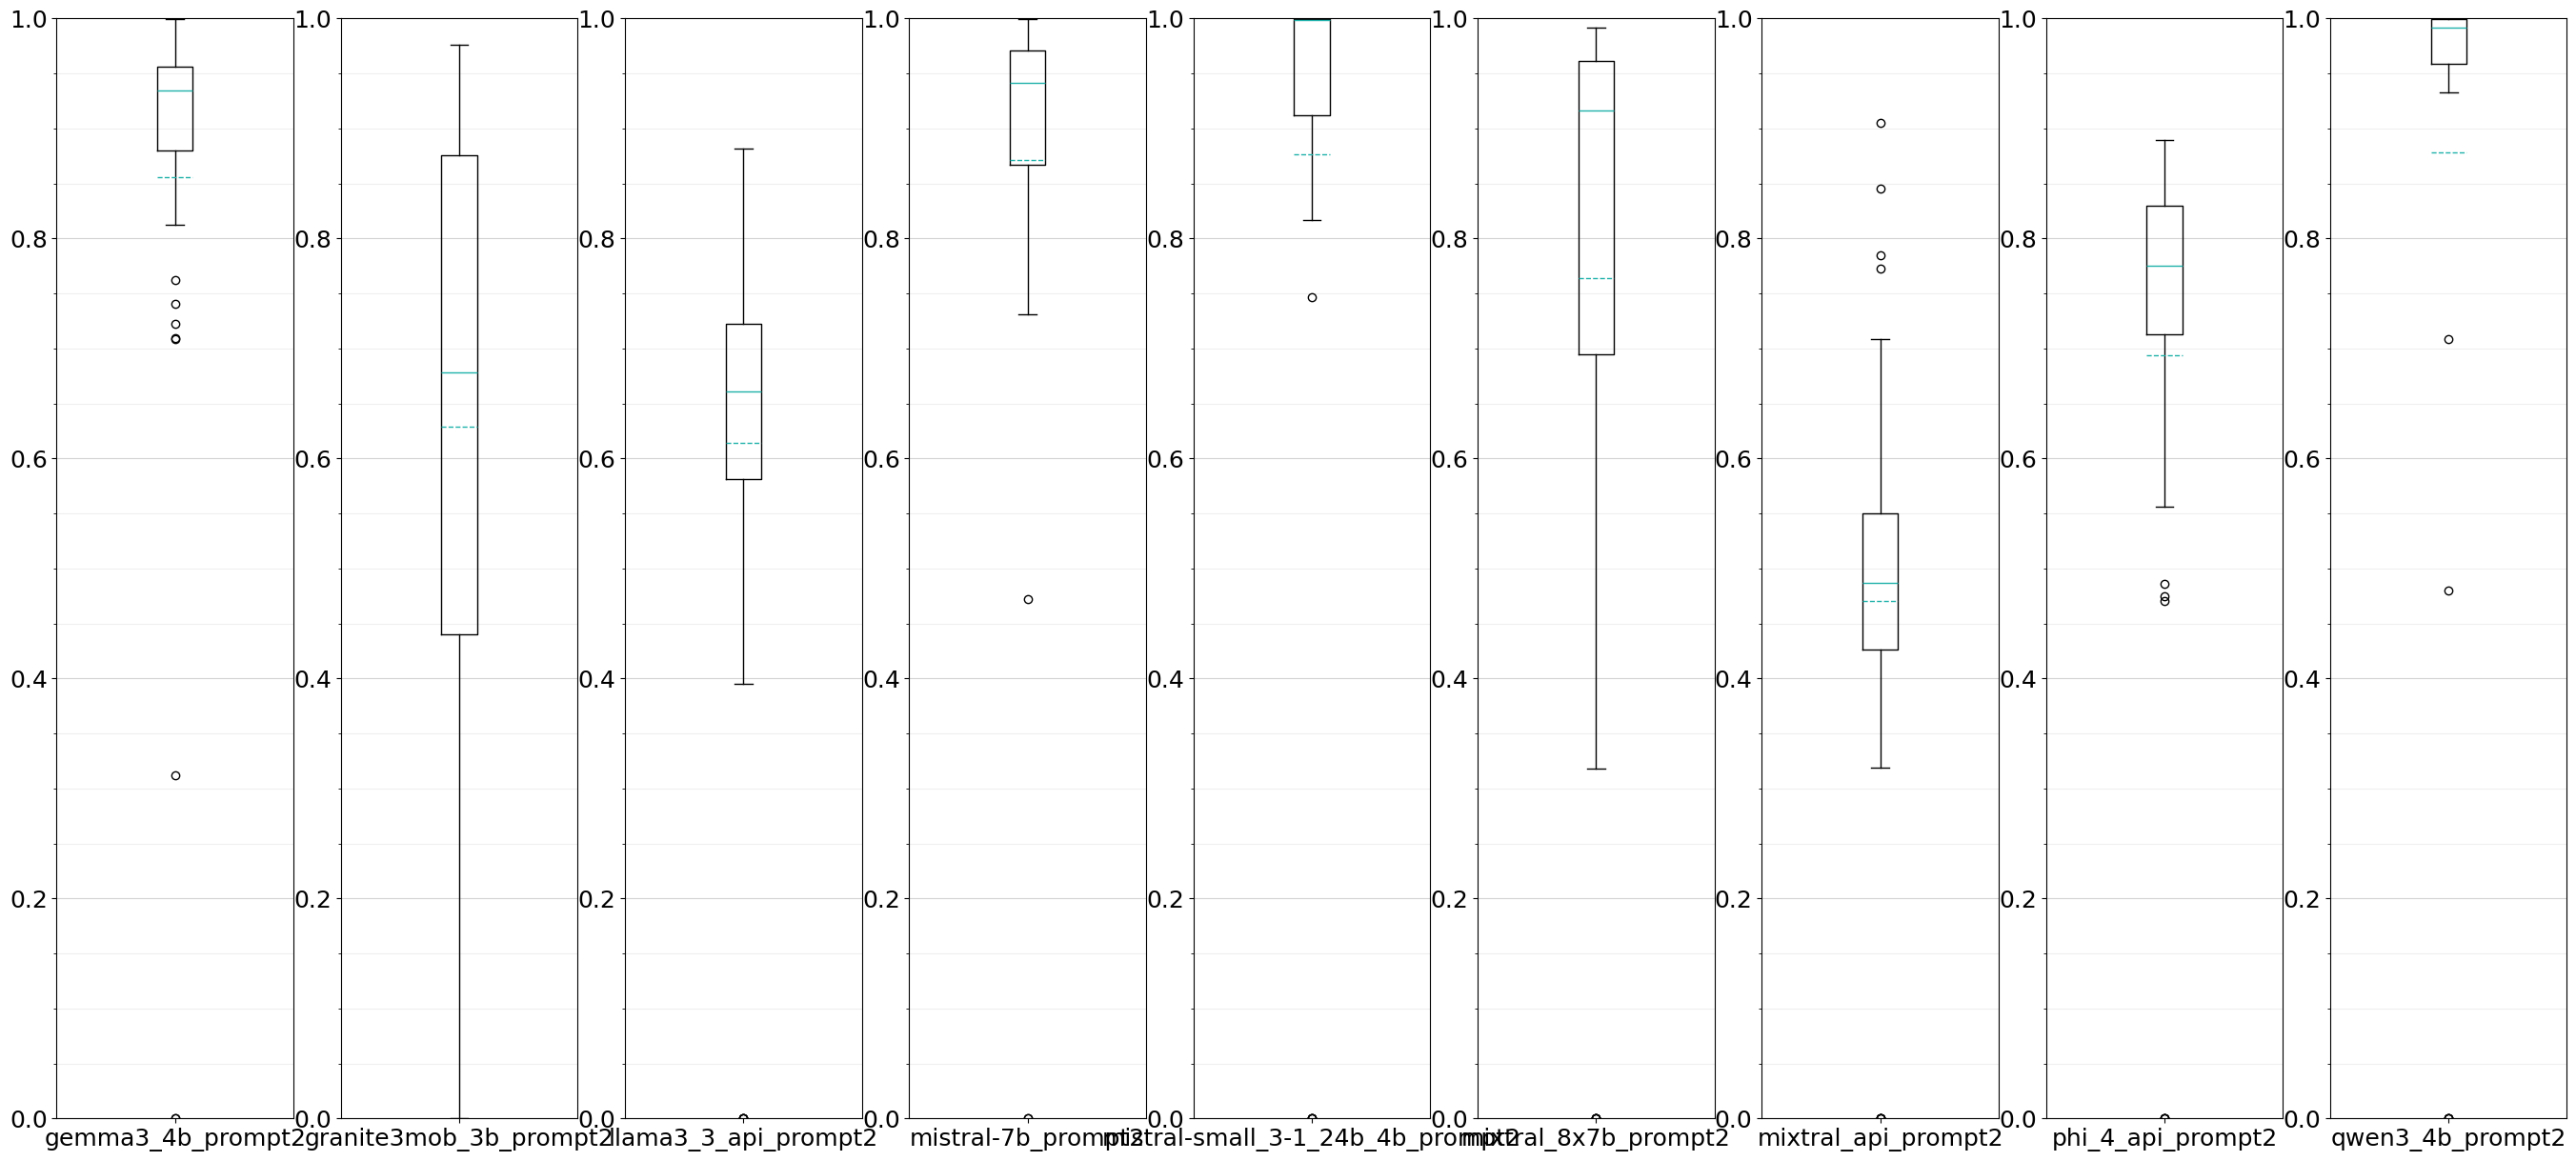

In [18]:
createBoxplot([[score_list[1]], 
               [score_list[3]],
               [score_list[5]],
               [score_list[7]],
               [score_list[9]],
               [score_list[11]],
               [score_list[13]],
               [score_list[15]],
               [score_list[17]]],
               [[provider_list[1][17:-3]],
               [provider_list[3][17:-3]],
               [provider_list[5][17:-3]],
               [provider_list[7][17:-3]],
               [provider_list[9][17:-3]],
               [provider_list[11][17:-3]],
               [provider_list[13][17:-3]],
               [provider_list[15][17:-3]],
               [provider_list[17][17:-3]]],               
               ["", "", "", "", "", "", "", "", ""],
               "Ergebnis des Prompt 2 mit Gemma3 4B zur Extrahierung der Inhalte")

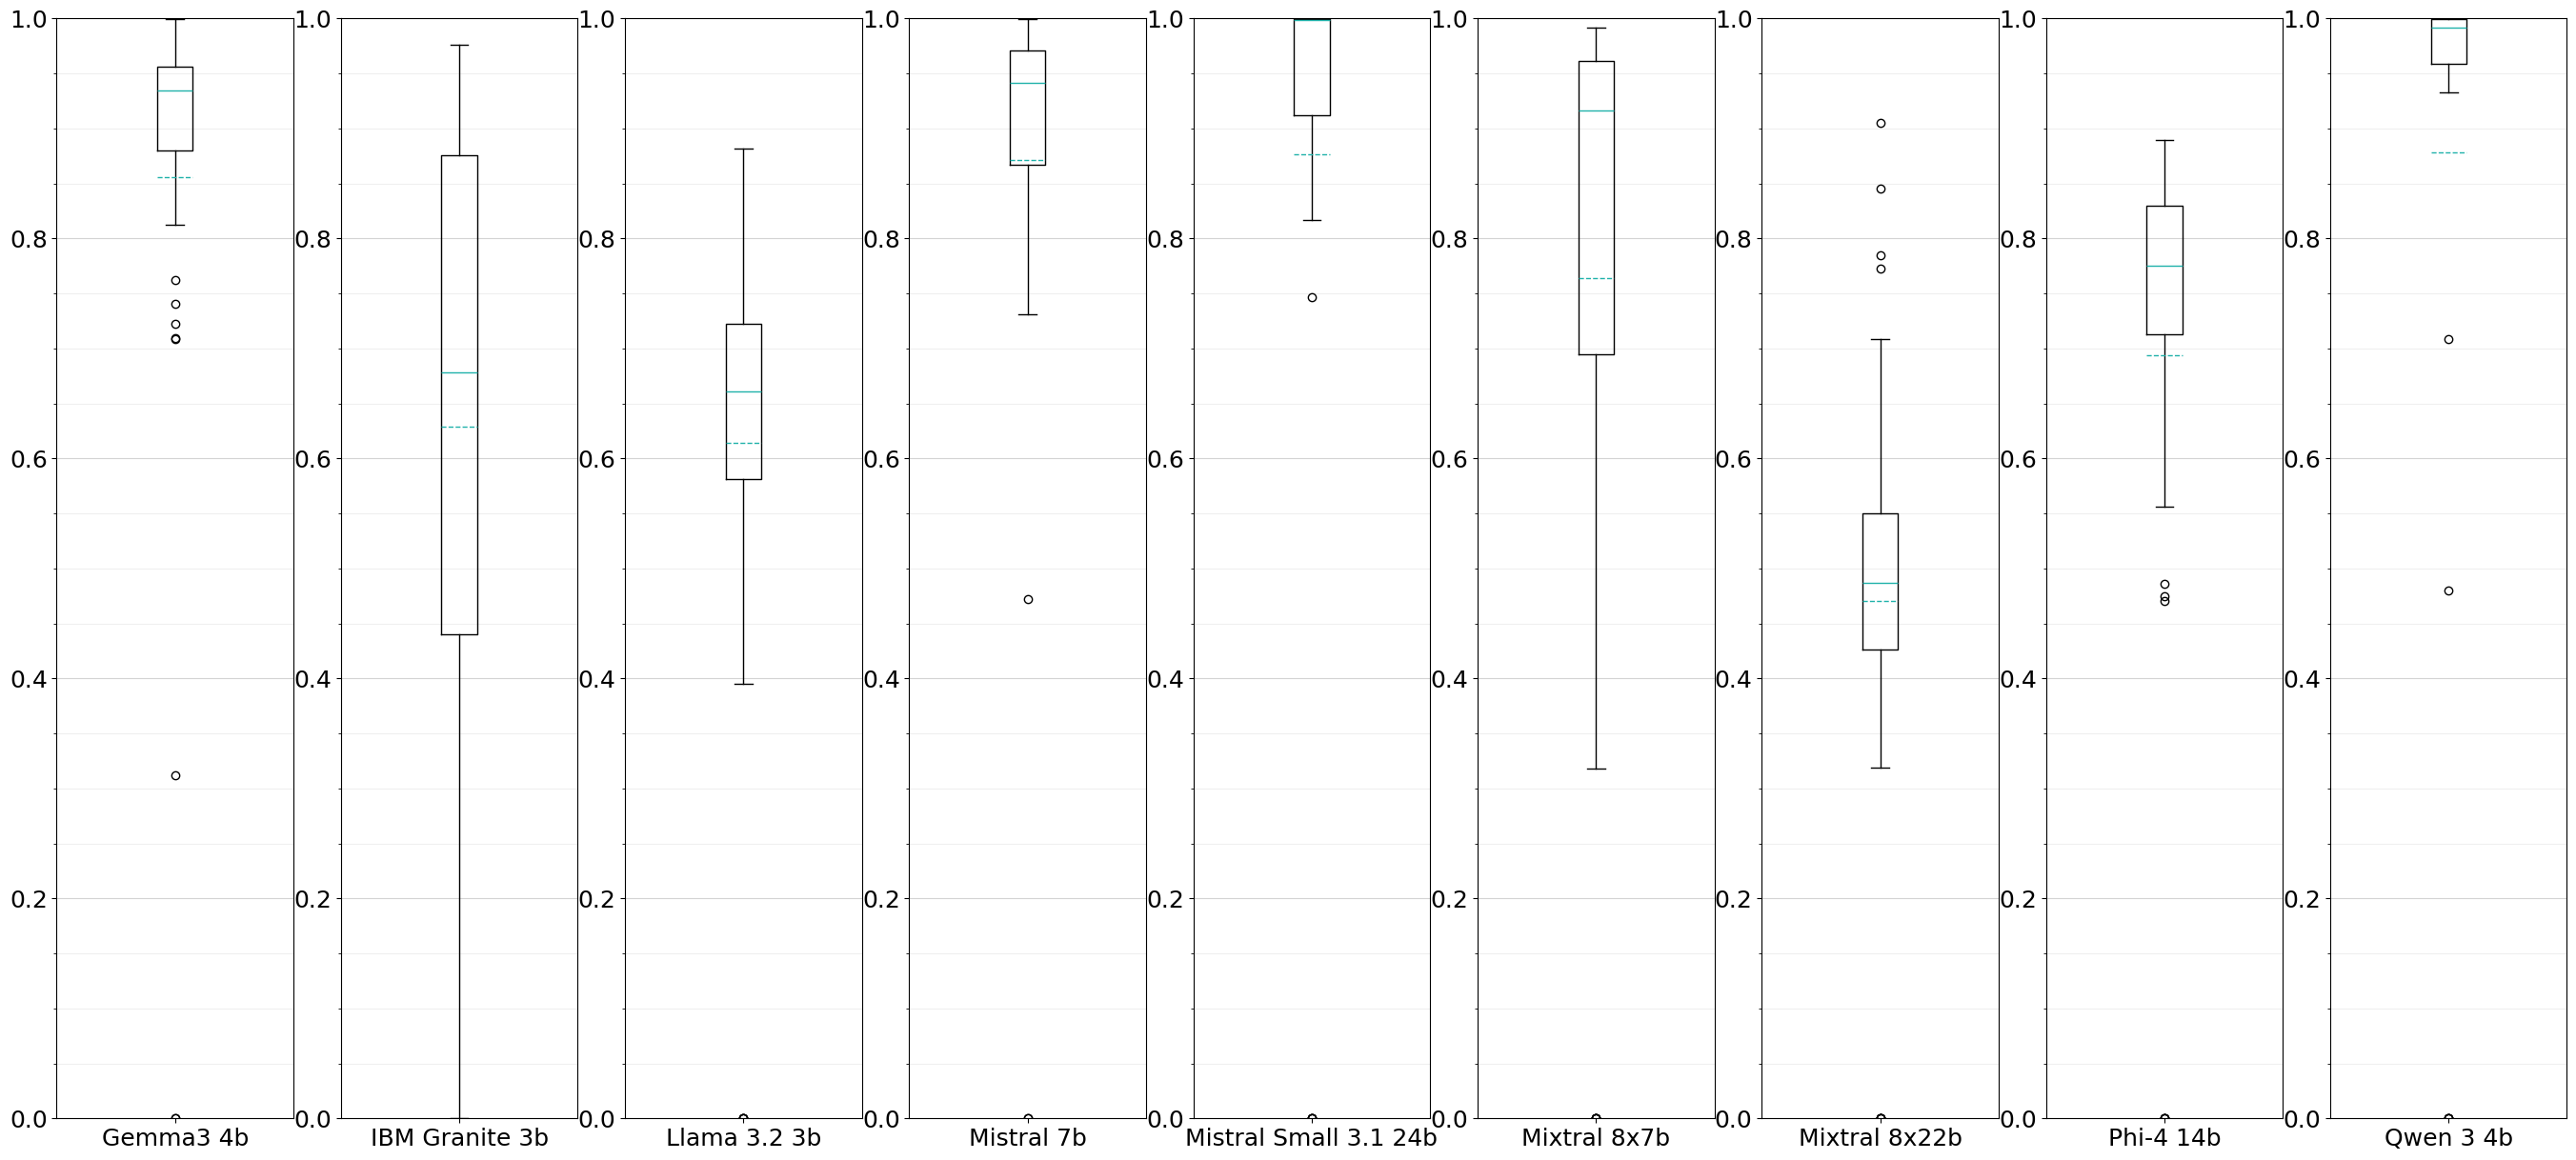

In [19]:
createBoxplot([[score_list[1]], 
               [score_list[3]],
               [score_list[5]],
               [score_list[7]],
               [score_list[9]],
               [score_list[11]],
               [score_list[13]],
               [score_list[15]],
               [score_list[17]]],
               [["Gemma3 4b"],
               ["IBM Granite 3b"],
               ["Llama 3.2 3b"],
               ["Mistral 7b"],
               ["Mistral Small 3.1 24b"],
               ["Mixtral 8x7b"],
               ["Mixtral 8x22b"],
               ["Phi-4 14b"],
               ["Qwen 3 4b"]],               
               ["", "", "", "", "", "", "", "", ""],
               "Ergebnis des Prompt 2 mit Gemma3 4B zur Extrahierung der Inhalte")

In [ ]:
provider_list[0][17:-3]

'gemma3_4b_prompt1'